# Mean Shift

## ¿Qué es?

Algoritmo basado en **modas** (centros de densidad). Funciona desplazando cada punto iterativamente hacia la región de mayor densidad (la "moda").

Características:
- **No necesita K**: el número de clusters se determina automáticamente
- Ventana (bandwidth) define el radio de búsqueda de densidad
- Tiende a encontrar clusters esféricos de similar densidad


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler

%matplotlib inline


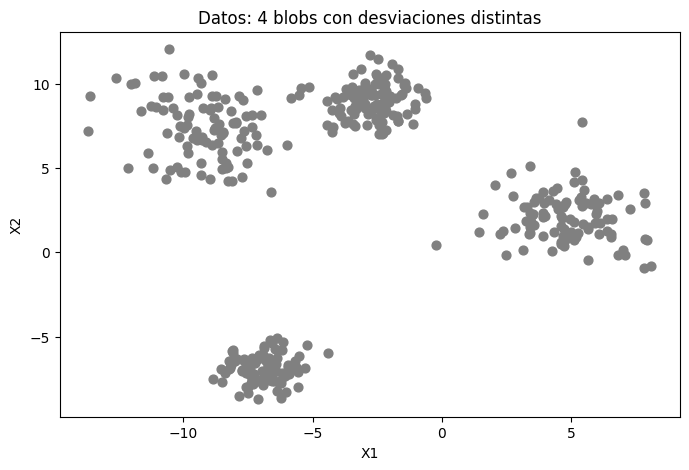

In [2]:
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=[1.0, 1.5, 0.8, 1.8], random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', s=40)
plt.title('Datos: 4 blobs con desviaciones distintas')
plt.xlabel('X1'); plt.ylabel('X2')
plt.show()


## Paso 1: Estimar bandwidth automáticamente


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

bandwidth = estimate_bandwidth(X_scaled, quantile=0.15, n_samples=300, random_state=42)
print(f'Bandwidth estimado: {bandwidth:.4f}')


Bandwidth estimado: 0.3882


## Paso 2: Aplicar Mean Shift


In [4]:
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels = ms.fit_predict(X_scaled)

labels_unique = np.unique(labels)
n_clusters = len(labels_unique)
centros_escalados = ms.cluster_centers_
centros_originales = scaler.inverse_transform(centros_escalados)

print(f'Número de clusters encontrados: {n_clusters}')
print('Centros (en escala escalada / estandarizada):')
print(np.round(centros_escalados, 3))
print()
print('Centros (en escala ORIGINAL, para plotear con X):')
print(np.round(centros_originales, 3))


Número de clusters encontrados: 5
Centros (en escala escalada / estandarizada):
[[-0.639 -1.544]
 [ 0.148  0.953]
 [ 1.507 -0.127]
 [-0.976  0.692]
 [ 1.625  0.762]]

Centros (en escala ORIGINAL, para plotear con X):
[[-6.908 -6.973]
 [-2.624  8.967]
 [ 4.766  2.073]
 [-8.737  7.305]
 [ 5.412  7.752]]


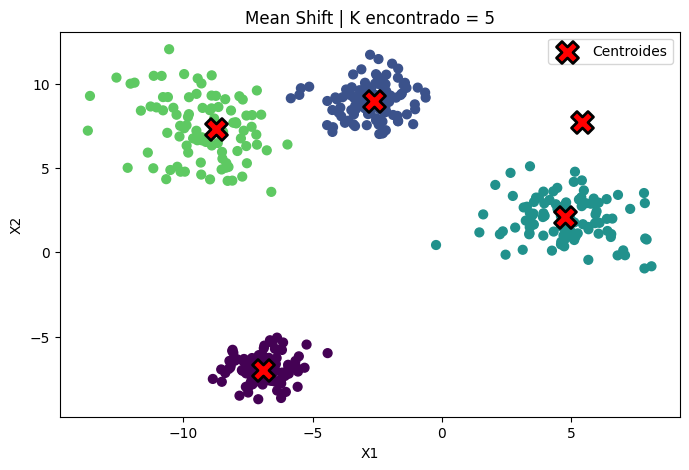

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
plt.scatter(centros_originales[:, 0], centros_originales[:, 1],
            marker='X', s=250, c='red', edgecolors='black', linewidths=2, label='Centroides')
plt.title(f'Mean Shift | K encontrado = {n_clusters}')
plt.legend()
plt.xlabel('X1'); plt.ylabel('X2')
plt.show()


## Paso 3: Probar diferentes quantiles para bandwidth


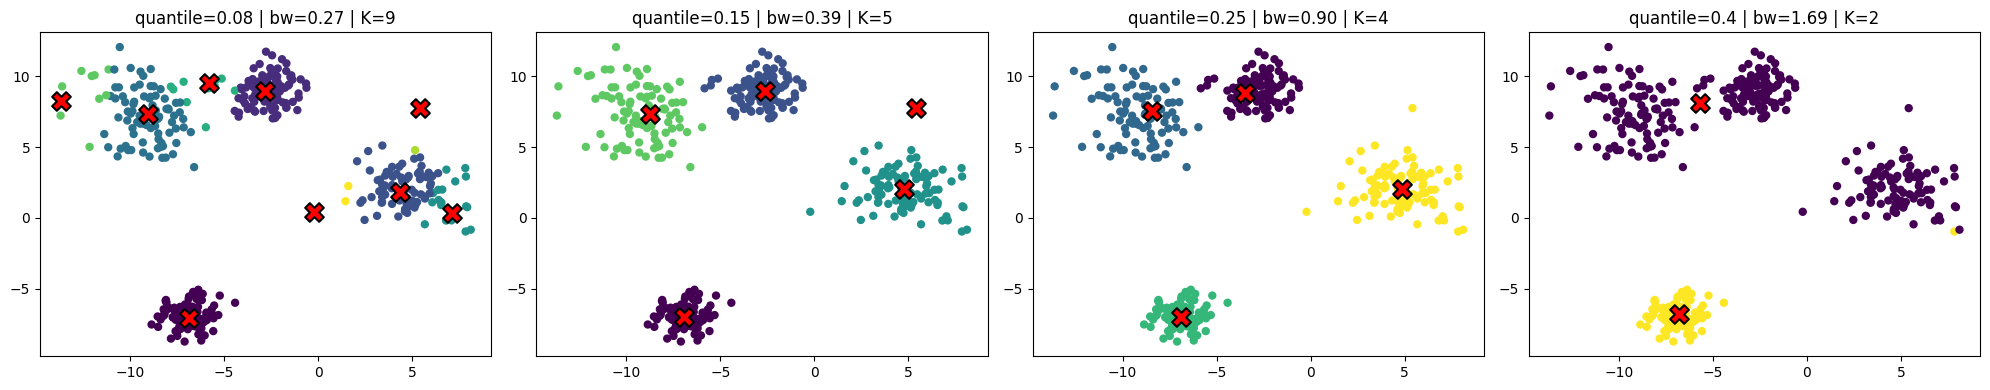

In [6]:
quantiles = [0.08, 0.15, 0.25, 0.4]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, q in enumerate(quantiles):
    bw = estimate_bandwidth(X_scaled, quantile=q, n_samples=300, random_state=42)
    ms_tmp = MeanShift(bandwidth=bw, bin_seeding=True)
    lbls = ms_tmp.fit_predict(X_scaled)
    n = len(np.unique(lbls))
    ctrs_orig = scaler.inverse_transform(ms_tmp.cluster_centers_)
    axes[i].scatter(X[:, 0], X[:, 1], c=lbls, cmap='viridis', s=25)
    axes[i].scatter(ctrs_orig[:, 0], ctrs_orig[:, 1],
                    marker='X', s=180, c='red', edgecolors='black', linewidths=1.5)
    axes[i].set_title(f'quantile={q} | bw={bw:.2f} | K={n}')
plt.tight_layout()
plt.show()


## Resumen

| Ventaja | Desventaja |
|---|---|
No necesita K | Sensible a bandwidth |
Detecta automáticamente clusters | Lento (computacionalmente caro) |
Formas no tan rígidas como K-means | No escala bien con muchos datos |
